#### Imports


In [30]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import re
import os 
from sklearn.model_selection import train_test_split

print("All impoorts successful")

All impoorts successful


In [31]:
# define file path 
RAW_DATA_PATH = "../data/raw/SQLiV3.csv"
PROCESSED_DIR = "../data/processed/"
CLEAN_DATA_PATH = "../data/processed/sqliv3_clean.csv"
TRAIN_SPLIT_PATH = "../data/processed/train_split.csv"
TEST_SPLIT_PATH = "../data/processed/test_split.csv"

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs("../results/figures/", exist_ok=True)


print("Paths defined and folders ready")

Paths defined and folders ready


In [32]:
# load the raw SQLiv3 dataset 

df= pd.read_csv(RAW_DATA_PATH, encoding='utf-8') #read dataset
df.head(10)

,Sentence,Label,Unnamed: 2,Unnamed: 3
0,""" or pg_sleep ( __TIME__ ) --",1,NaN,NaN
1,create user name identified by pass123 tempora...,NaN,1,NaN
2,AND 1 = utl_inaddr.get_host_address ( ...,1,NaN,NaN
3,select * from users where id = '1' or @ @1 ...,1,NaN,NaN
4,"select * from users where id = 1 or 1#"" ( ...",1,NaN,NaN
5,select name from syscolumns where id = ...,1,NaN,NaN
6,select * from users where id = 1 +$+ or 1 =...,1,NaN,NaN
7,"1; ( load_file ( char ( 47,101,116,99,47...",1,NaN,NaN
8,select * from users where id = '1' or ||/1 ...,1,NaN,NaN
9,select * from users where id = '1' or \.<\ ...,1,NaN,NaN


In [33]:
#remove unused columns 
del df['Unnamed: 2']

del df['Unnamed: 3']

print("shape:", df.shape)

df.head()


shape: (30919, 2)


,Sentence,Label
0,""" or pg_sleep ( __TIME__ ) --",1
1,create user name identified by pass123 tempora...,NaN
2,AND 1 = utl_inaddr.get_host_address ( ...,1
3,select * from users where id = '1' or @ @1 ...,1
4,"select * from users where id = 1 or 1#"" ( ...",1


In [34]:
# Inspect the dataset structure


print("----------------------------------------------------")
df.info()
print("----------------------------------------------------")
print()
df['Label'].describe()

----------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 30919 entries, 0 to 30918
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Sentence  30904 non-null  str  
 1   Label     30664 non-null  str  
dtypes: str(2)
memory usage: 483.2 KB
----------------------------------------------------



count     30664
unique       42
top           0
freq      19268
Name: Label, dtype: object

##### Process NaN values 

In [35]:
#count NaN labels values 

print(f"NaN values in Label column:{df['Label'].isna().sum()}")

NaN values in Label column:255


In [36]:
# drop NaN rows 

df = df.dropna()
print(f"shape:{df.shape}")

shape:(30649, 2)


##### Fixing the target labels 

In [37]:
#show unique values before fixing 

unique_label =pd.unique(df['Label'])

print("Unique values in Label column:")

print()

for l in unique_label:
  print(repr(l))

Unique values in Label column:

'1'
'SELECT *'
' --'
' desc users'
' OR'
"waitfor delay '0:0:__TIME__'--"
' drop table temp --'
'0'
' grant resource to name'
' EXEC SelectAllCustomers'
' /*Select all the columns of all the records in the Customers table:*/'
'*/'
' CREATE VIEW [Products Above Average Price] AS'
' CREATE OR REPLACE VIEW view_name AS'
' DROP TABLE Suppliers'
' CREATE PROCEDURE SelectAllCustomers AS'
'  EXEC SelectAllCustomers'
" DELETE FROM Customers  WHERE CustomerName = 'Alfreds Futterkiste'"
' CREATE OR REPLACE VIEW [Brazil Customers] AS'
'  SELECT * FROM CustomersLIMIT 3'
'SELECT * FROM Customers'
' SELECT TOP 50 PERCENT * FROM Customers'
' SELECT * FROM CustomersFETCH FIRST 50 PERCENT ROWS ONLY'
'SELECT TOP 3 * FROM Customers'
' SELECT * FROM Customers'
'SELECT SUM ( Quantity ) '
' SELECT column_name ( s ) '
' SELECT City FROM Customers'


In [38]:
# fix the Label column 

df = df.drop(df[(df['Label'] !='0') & (df['Label'] != '1')].index)

df['Label']= df['Label'].astype('int')

df.info()

<class 'pandas.DataFrame'>
Index: 30609 entries, 0 to 30918
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Sentence  30609 non-null  str  
 1   Label     30609 non-null  int64
dtypes: int64(1), str(1)
memory usage: 717.4 KB


In [39]:
# count malicious and benign samples 

print("Malacious samples:")
print(df[df['Label']==1].count())

print()

print("Benign smaples:")
print(df[df['Label']==0].count())

Malacious samples:
Sentence    11341
Label       11341
dtype: int64

Benign smaples:
Sentence    19268
Label       19268
dtype: int64


##### Label Distribution 

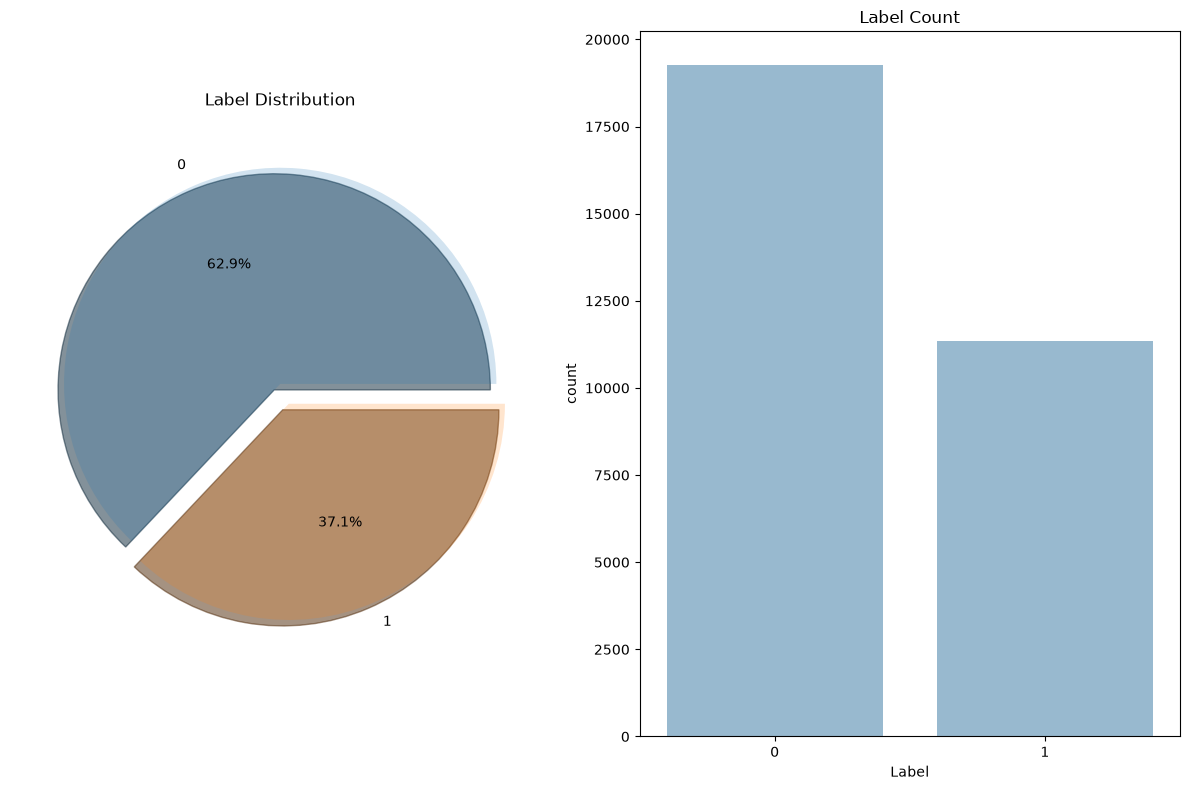

Chart saved


In [40]:
# Visualise label distribution

f, ax = plt.subplots(1, 2, figsize=(12, 8))

# Pie chart
df['Label'].value_counts().plot.pie(
    explode=[0, 0.1],
    autopct='%1.1f%%',
    ax=ax[0],
    shadow=True,
    wedgeprops={'alpha': 0.2}
)
ax[0].set_title('Label Distribution')
ax[0].set_ylabel('')

# Bar chart
sns.countplot(x='Label', data=df, ax=ax[1], alpha=0.5)
ax[1].set_title('Label Count')

plt.tight_layout()
plt.savefig('../results/figures/label_distribution.png', dpi=150)
plt.show()

print("Chart saved")

In [41]:
# Identify SQl injection types in the malicious samples 

mal = df[df["Label"]==1].copy()

#Define each attack and its pattern

sqli_types ={
  'Tautology': r"(?i)(\d+\s*=\s*\d+|'\w+'\s*=\s*'\w+'|or\s+\d+\s*=\s*\d+)",
    'Error-based':     r'(?i)(extractvalue|updatexml|floor\s*\(\s*rand)',
    'Time-based':      r'(?i)(sleep\s*\(|waitfor\s+delay|pg_sleep\s*\(|benchmark\s*\()',
    'Stacked queries': r';.{1,}(select|insert|update|delete|drop)',
    'Comment-based':   r'(--|#|/\*[\s\S]*?\*/)',
    'Boolean-based':   r'(?i)\b(and|or)\b\s+[\w\'\"]+\s*(=|<|>|like|between)',
    'Union-based': r'(?i)\bunion\b',
}

type_counts = {}
for name, pattern in sqli_types.items():
  count = mal['Sentence'].str.contains(pattern, regex=True, na=False).sum()
  type_counts[name]=count


print(f"Total malicious samples: {len(mal):,}")
print()
print(f"{'Attack Type':<22} {'Count':>8} {'Percentage':>12}")
print("-" * 45)
for name, count in type_counts.items():
    pct = count / len(mal) * 100
    print(f"{name:<22} {count:>8,} {pct:>11.1f}%")

print()
print("Note: one query can belong to more than one category.")

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_15804\4194670535.py:19: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  count = mal['Sentence'].str.contains(pattern, regex=True, na=False).sum()


Total malicious samples: 11,341

Attack Type               Count   Percentage
---------------------------------------------
Tautology                 6,899        60.8%
Error-based                 648         5.7%
Time-based                1,576        13.9%
Stacked queries               9         0.1%
Comment-based             5,896        52.0%
Boolean-based             4,054        35.7%
Union-based               2,218        19.6%

Note: one query can belong to more than one category.


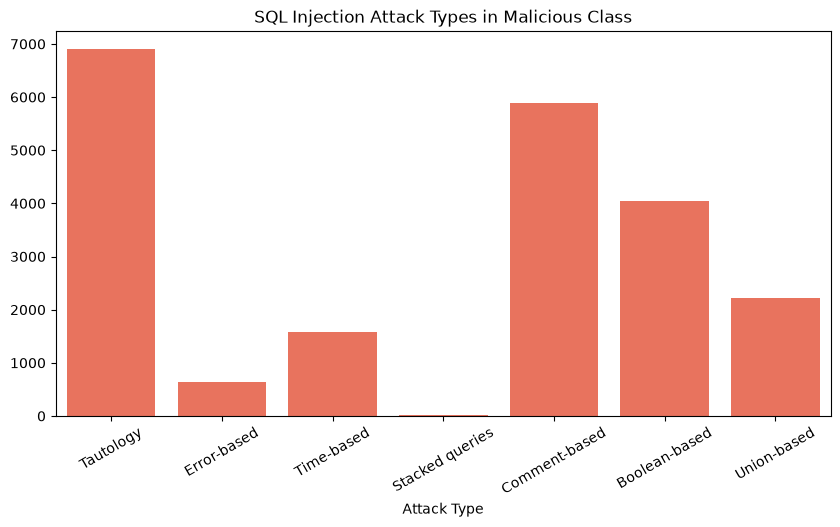

Chart saved


In [42]:

# Plot SQL injection type distribution

plt.figure(figsize=(10, 5))


sns.barplot(x=list(type_counts.keys()), y=list(type_counts.values()), color='tomato')


plt.title('SQL Injection Attack Types in Malicious Class')
plt.xlabel('Attack Type')


plt.xticks(rotation=30)


plt.savefig('../results/figures/sqli_types.png')
plt.show()

print("Chart saved")


Word                  Frequency
--------------------------------
)                        45,252
(                        40,095
=                        13,701
select                    9,999
and                       6,024
||chr                     5,714
as                        5,109
from                      4,297
where                     4,069
1                         3,992


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_15804\1325936846.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=words, y=freqs, palette='Blues_d')


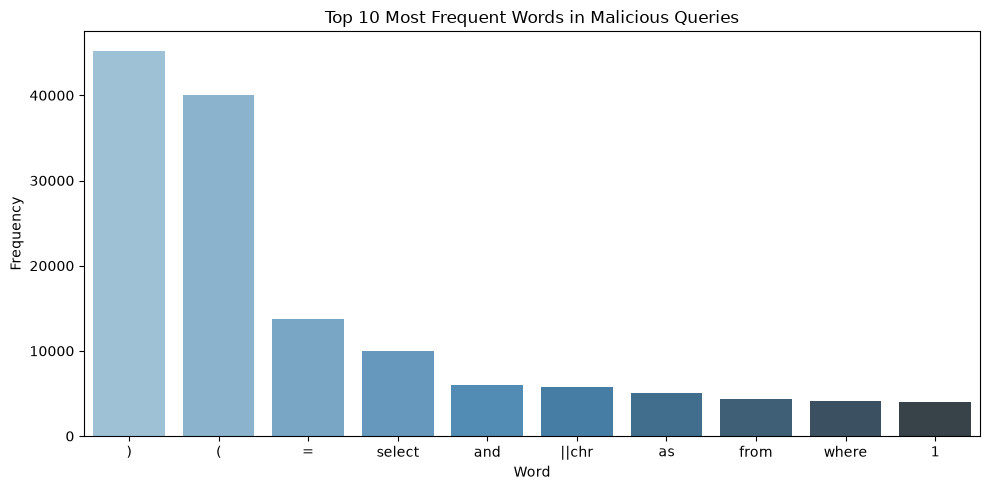

In [43]:
# Top 10 most frequent words in malicious queries
from collections import Counter

all_words = ' '.join(df[df['Label'] == 1]['Sentence'].tolist()).lower().split()
word_counts = Counter(all_words)
top_10 = word_counts.most_common(10)

print(f"{'Word':<20} {'Frequency':>10}")
print("-" * 32)
for word, freq in top_10:
    print(f"{word:<20} {freq:>10,}")

words = [w for w, f in top_10]
freqs = [f for w, f in top_10]

plt.figure(figsize=(10, 5))
sns.barplot(x=words, y=freqs, palette='Blues_d')
plt.title('Top 10 Most Frequent Words in Malicious Queries')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('../results/figures/top_words_malicious.png', dpi=150)
plt.show()

In [44]:
#Audit obfuscation coverage in the malicious class 

obfuscation_checks = {
    'URL encoding (%XX)':       r'%[0-9a-fA-F]{2}',
    'Hex encoding (0x...)':     r'0x[0-9a-fA-F]+',
    'Mixed case keywords':      r'[A-Z][a-z][A-Z]|[a-z][A-Z][a-z]',
    'Block comments (/**/)':    r'/\*[\s\S]*?\*/',
    'CHAR() functions':         r'(?i)\bchr?\s*\(',
    'Space evasion via plus':   r'\+',                       # e.g., SELECT+*+FROM
    'Space evasion via comment': r'(?i)select/\*\*\/from',     # e.g., SELECT/**/FROM
    'String concatenation':     r"'\|\|'|\bconcat\b"         # e.g., 'sel'||'ect'
}

print("Obfuscation coverage in malicious class:")
print(f"{'Technique':<30} {'Count':>8} {'%':>8}")
print("-" * 50)

for name, pattern in obfuscation_checks.items():
    count = mal['Sentence'].str.contains(pattern, regex=True, na=False).sum()
    pct   = count / len(mal) * 100
    print(f"{name:<30} {count:>8,} {pct:>7.1f}%")

Obfuscation coverage in malicious class:
Technique                         Count        %
--------------------------------------------------
URL encoding (%XX)                    6     0.1%
Hex encoding (0x...)              1,228    10.8%
Mixed case keywords                   0     0.0%
Block comments (/**/)                 3     0.0%
CHAR() functions                    762     6.7%
Space evasion via plus              709     6.3%
Space evasion via comment             0     0.0%
String concatenation                875     7.7%


##### Final Cleaning Process

In [45]:
# drop short or empty sentence and reset index 
df = df.dropna(subset=['Sentence'])
df['Sentence'] = df['Sentence'].astype(str).str.strip()

df= df[df['Sentence'].str.len()>2]
df= df.reset_index(drop=True)


print(f"final dataset: {len(df):,} rows")
print(f"Malicious: {(df['Label']==1).sum():,}")
print(f"Benign:    {(df['Label']==0).sum():,}")

final dataset: 30,527 rows
Malicious: 11,304
Benign:    19,223


In [46]:
# check and remove duplicated rows 

print(f"Row before removing duplicates:{len(df):,}")

df = df.drop_duplicates(subset=['Sentence'], keep='first')
df = df.reset_index(drop=True)

print(f"Rows after removing duplicates:  {len(df):,}")

Row before removing duplicates:30,527
Rows after removing duplicates:  30,459


In [47]:
# Cell 16 - Final data quality check
print("Final data quality check")
print("-" * 40)
print(f"Total rows:     {len(df):,}")
print(f"Null sentences: {df['Sentence'].isnull().sum()}")
print(f"Null labels:    {df['Label'].isnull().sum()}")
print(f"Duplicates:     {df.duplicated(subset=['Sentence']).sum()}")
print(f"Malicious:      {(df['Label']==1).sum():,} ({(df['Label']==1).sum()/len(df)*100:.1f}%)")
print(f"Benign:         {(df['Label']==0).sum():,} ({(df['Label']==0).sum()/len(df)*100:.1f}%)")
print()
print("Data is clean and ready for splitting.")

Final data quality check
----------------------------------------
Total rows:     30,459
Null sentences: 0
Null labels:    0
Duplicates:     0
Malicious:      11,248 (36.9%)
Benign:         19,211 (63.1%)

Data is clean and ready for splitting.


##### Separating Obfuscated data

In [48]:
# Identify and separate obfuscated samples from the dataset


obfuscation_pattern = (
    r'%[0-9a-fA-F]{2}'           # URL encoding
    r'|0x[0-9a-fA-F]+'           # Hex encoding  
    r'|[A-Z][a-z][A-Z]'          # Mixed case
    r'|[a-z][A-Z][a-z]'          # Mixed case variant
    r'|/\*.*?\*/'                 # Block comments inside keywords
)

# Find rows that contain obfuscation
is_obfuscated = df['Sentence'].str.contains(
    obfuscation_pattern, regex=True, na=False
)

# Obfuscated malicious samples go to OOD pool
obfuscated_mal = df[is_obfuscated & (df['Label'] == 1)].copy()

# Everything else becomes the standard training pool
df_clean = df[~is_obfuscated].copy()
df_clean = df_clean.reset_index(drop=True)

print("Separation results:")
print(f"  Obfuscated malicious samples removed: {len(obfuscated_mal):,}")
print(f"  Standard training pool remaining:     {len(df_clean):,}")
print()
print(f"  Training pool malicious: {(df_clean['Label']==1).sum():,}")
print(f"  Training pool benign:    {(df_clean['Label']==0).sum():,}")

Separation results:
  Obfuscated malicious samples removed: 1,237
  Standard training pool remaining:     29,085

  Training pool malicious: 10,011
  Training pool benign:    19,074


In [51]:
# Save the obfuscated samples for use in Notebook 02


NATIVE_OOD_PATH = "../data/processed/native_obfuscated.csv"

# save into file 
obfuscated_mal.to_csv(NATIVE_OOD_PATH, index=False)

print(f"Native obfuscated samples saved: {len(obfuscated_mal):,} rows")
print(f"Saved to: {NATIVE_OOD_PATH}")
print()


Native obfuscated samples saved: 1,237 rows
Saved to: ../data/processed/native_obfuscated.csv



In [ ]:
# Cell 16c - Analyse class balance on the training pool
# This informs our training weights strategy
mal_count = (df_standard_pool['Label'] == 1).sum()
ben_count = (df_standard_pool['Label'] == 0).sum()
total     = len(df_standard_pool)
ratio     = round(ben_count / mal_count, 2)

print("Class Balance Analysis (Standard Training Pool):")
print("-" * 40)
print(f"  Malicious (1): {mal_count:,}  ({mal_count/total*100:.1f}%)")
print(f"  Benign    (0): {ben_count:,}  ({ben_count/total*100:.1f}%)")
print(f"  Imbalance ratio (benign:malicious): {ratio:.2f}")
print()

if ratio >= 1.5:
    print("Imbalance detected. Strategy: class_weight='balanced' will be applied.")
else:
    print("Class balance is acceptable. No correction needed.")


Class Balance Analysis (Standard Training Pool):
----------------------------------------
  Malicious (1): 10,014  (34.3%)
  Benign    (0): 19,180  (65.7%)
  Imbalance ratio (benign:malicious): 1.92

Imbalance detected. Strategy: class_weight='balanced' will be applied.
